<a href="https://colab.research.google.com/github/hariomlohardev/AGI_Research/blob/main/Projects/small_projects/PCA_with_MNIST-lite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install matplotlib  pillow numpy

In [2]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt


In [3]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
digits = load_digits()
X = digits.data      # Shape: (1797, 64) -> 1797 handwritten digits, 64 pixels each
y = digits.target    # Shape: (1797,) -> The actual digit (0, 1, 2, ..., 9)

# To visualize a single digit, you can run this:
# plt.imshow(X[0].reshape(8, 8), cmap='gray')
# plt.show()



# TRAIN SECTION

## Train test spleting with 85%

In [4]:
x_train ,y_train ,x_test ,y_test = [],[],[],[]

In [5]:
x_train = X[:1527]
y_train = y[:1527]

In [6]:
x_test = X[1527:]
y_test = y[1527:]

In [7]:
X.shape

(1797, 64)

In [8]:
x_train.shape

(1527, 64)

## Now we will convert the 64D to 2D

In [9]:
mean_x = np.mean(x_train ,axis=0)

In [10]:
x_train_centered = x_train - mean_x

In [11]:
x_train_centered.shape

(1527, 64)

LEGENDREY SVD singluar value decomposition

In [12]:
U ,S ,Vt =np.linalg.svd(x_train_centered , full_matrices=False)

In [13]:
V = Vt.T

In [14]:
V.shape

(64, 64)

In [15]:
V_2 = V[:, :33]

In [16]:
V_2.shape

(64, 33)

Projection of matrix


In [17]:
X_train_projection  = x_train_centered @ V_2

In [18]:
X_train_projection.shape

(1527, 33)

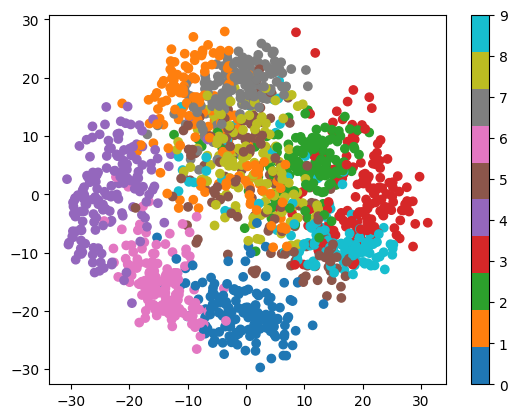

In [19]:
plt.scatter(X_train_projection[:,0],X_train_projection[:,1] , c =y_train,cmap='tab10')
plt.colorbar()
plt.show()

New Section

# TEST SECTION

In [20]:
k= 2

In [21]:
test_x = x_test[k]

In [22]:
test_x.shape

(64,)

In [23]:
# test_x_mean = np.mean(test_x ,axis=0)

In [24]:
# test_x_mean

In [25]:
test_x_centerd = test_x - mean_x

In [26]:
test_x_centerd.shape

(64,)

In [27]:
projection_test_x = test_x_centerd @ V_2

finding the distance

In [28]:
distances =np.linalg.norm(X_train_projection - projection_test_x, axis=1)

In [29]:
closest_nighbour  = np.argmin(distances)

In [30]:
closest_nighbour

np.int64(829)

In [31]:
y_train[closest_nighbour]

np.int64(8)

In [32]:
y_test[k]

np.int64(8)


  predicted No : 6
  actual No : 6
  


[6, 6]

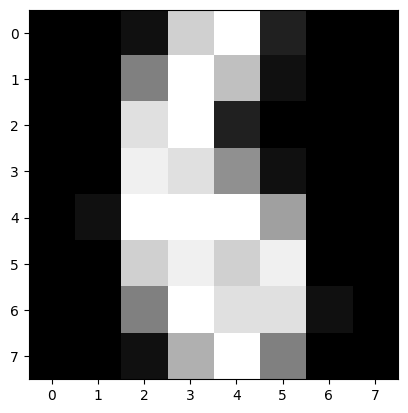

In [33]:
def test(k):
  test_x = x_test[k]
  test_x_mean = np.mean(test_x ,axis=0)
  test_x_centerd = test_x - test_x_mean
  projection_test_x = test_x_centerd @ V_2
  distances =np.linalg.norm(X_train_projection - projection_test_x, axis=1)
  closest_nighbour  = np.argmin(distances)
  plt.imshow(test_x.reshape(8,8), cmap ='gray')
  plt.show
  print(f"""
  predicted No : {y_train[closest_nighbour]}
  actual No : {y_test[k]}
  """)
  result =  [int(y_test[k]) ,int(y_train[closest_nighbour])]
  return result


test(120)



  predicted No : 7
  actual No : 7
  
[7, 7]


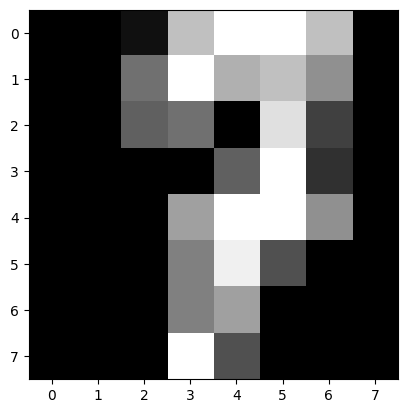

In [34]:
print(test(0))


  predicted No : 7
  actual No : 7
  

  predicted No : 7
  actual No : 7
  

  predicted No : 2
  actual No : 2
  

  predicted No : 2
  actual No : 2
  

  predicted No : 8
  actual No : 8
  

  predicted No : 8
  actual No : 8
  

  predicted No : 2
  actual No : 2
  

  predicted No : 2
  actual No : 2
  

  predicted No : 2
  actual No : 2
  

  predicted No : 2
  actual No : 2
  

  predicted No : 5
  actual No : 5
  

  predicted No : 5
  actual No : 5
  

  predicted No : 7
  actual No : 7
  

  predicted No : 7
  actual No : 7
  

  predicted No : 9
  actual No : 9
  

  predicted No : 9
  actual No : 9
  

  predicted No : 5
  actual No : 5
  

  predicted No : 5
  actual No : 5
  

  predicted No : 4
  actual No : 4
  

  predicted No : 4
  actual No : 4
  

  predicted No : 8
  actual No : 8
  

  predicted No : 8
  actual No : 8
  

  predicted No : 8
  actual No : 8
  

  predicted No : 8
  actual No : 8
  

  predicted No : 4
  actual No : 4
  

  predicted No : 4
  act

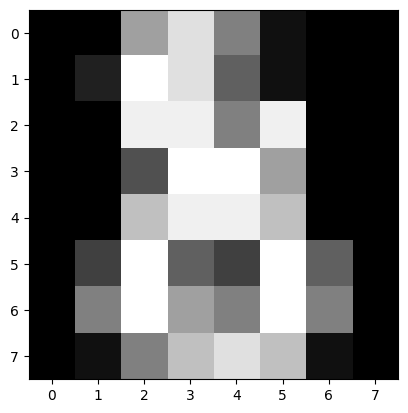

In [35]:
score = 0
for i in range(270):
  actual_digit ,predicted_digit = test(i)[0] ,test(i)[1]
  if predicted_digit == actual_digit:
    score = score + 1
accuracy = (score/270) * 100
print(f"accuracy: {accuracy}")